In [ ]:
print("==========================================")
print("         ECOSPACE MONITORAMENTO")
print(" Sistema Inteligente de Monitoramento")
print(" Energias Renováveis em Missão Espacial")
print("==========================================")

In [22]:
historico = []
limite_leituras = 50

In [23]:
def inserir_dados():
    if len(historico) >= limite_leituras:
        print("Limite de leituras atingido.")
        return

    print("\n--- INSERIR DADOS DA MISSÃO ---")

    temperatura = float(input("Digite a temperatura em °C: "))
    energia = float(input("Digite o nível de energia em %: "))
    potencia = float(input("Digite a potência consumida em watts: "))
    energia_solar = float(input("Digite a energia solar captada em %: "))

    comunicacao = input("A comunicação está funcionando? (sim/não): ").lower()
    modulo_ativo = input("O sistema está ativo? (sim/não): ").lower()

    if energia < 0:
        energia = 0
    elif energia > 100:
        energia = 100

    if energia_solar < 0:
        energia_solar = 0
    elif energia_solar > 100:
        energia_solar = 100

    leitura = {
        "temperatura": temperatura,
        "energia": energia,
        "potencia": potencia,
        "energia_solar": energia_solar,
        "comunicacao": comunicacao,
        "modulo_ativo": modulo_ativo
    }

    historico.append(leitura)

    print("\nDados registrados com sucesso!")
    analisar_leitura(leitura)

In [24]:
def analisar_leitura(leitura):
    pontos_risco = 0

    print("\n--- ANÁLISE INTELIGENTE ---")

    if leitura["temperatura"] <= 55:
        print("Temperatura: segura")
    elif leitura["temperatura"] <= 80:
        print("Temperatura: elevada, precisa de atenção")
        pontos_risco += 1
    else:
        print("Temperatura: risco de superaquecimento")
        pontos_risco += 2

    if leitura["energia"] >= 60:
        print("Energia: nível estável")
    elif leitura["energia"] >= 30:
        print("Energia: nível moderado")
        pontos_risco += 1
    else:
        print("Energia: nível crítico")
        pontos_risco += 2

    if leitura["energia_solar"] >= 60:
        print("Energia solar: captação eficiente")
    elif leitura["energia_solar"] >= 30:
        print("Energia solar: captação média")
        pontos_risco += 1
    else:
        print("Energia solar: captação baixa")
        pontos_risco += 2

    if leitura["potencia"] <= 500:
        print("Potência: consumo controlado")
    elif leitura["potencia"] <= 700:
        print("Potência: consumo elevado")
        pontos_risco += 1
    else:
        print("Potência: consumo excessivo")
        pontos_risco += 2

    if leitura["comunicacao"] == "sim":
        print("Comunicação: funcionando")
    else:
        print("Comunicação: falha detectada")
        pontos_risco += 2

    if leitura["modulo_ativo"] == "sim":
        print("Sistema: ativo")
    else:
        print("Sistema: inativo")
        pontos_risco += 2

    print("\n--- DECISÃO AUTOMÁTICA ---")

    if pontos_risco == 0:
        print("Resultado da análise: missão operando normalmente.")
        print("Ação recomendada: manter monitoramento padrão.")
    elif pontos_risco <= 3:
        print("Resultado da análise: missão em atenção.")
        print("Ação recomendada: reduzir consumo e acompanhar os dados.")
    elif pontos_risco <= 6:
        print("Resultado da análise: missão em risco.")
        print("Ação recomendada: ativar modo economia e priorizar energia solar.")
    else:
        print("Resultado da análise: situação crítica.")
        print("Ação recomendada: ativar modo de segurança e enviar aviso para a base.")

In [25]:
def status_atual():
    if len(historico) == 0:
        print("Nenhuma leitura registrada.")
        return

    ultima = historico[-1]

    print("\n--- STATUS ATUAL DA MISSÃO ---")
    print(f"Temperatura: {ultima['temperatura']} °C")
    print(f"Energia: {ultima['energia']}%")
    print(f"Potência consumida: {ultima['potencia']} W")
    print(f"Energia solar captada: {ultima['energia_solar']}%")
    print(f"Comunicação: {ultima['comunicacao']}")
    print(f"Sistema ativo: {ultima['modulo_ativo']}")

    analisar_leitura(ultima)

In [26]:
def analise_completa():
    if len(historico) == 0:
        print("Nenhuma leitura registrada.")
        return

    temperaturas = []
    energias = []
    potencias = []
    solares = []

    falhas_comunicacao = 0
    sistemas_inativos = 0

    for leitura in historico:
        temperaturas.append(leitura["temperatura"])
        energias.append(leitura["energia"])
        potencias.append(leitura["potencia"])
        solares.append(leitura["energia_solar"])

        if leitura["comunicacao"] != "sim":
            falhas_comunicacao += 1

        if leitura["modulo_ativo"] != "sim":
            sistemas_inativos += 1

    print("\n--- ANÁLISE COMPLETA DA MISSÃO ---")
    print(f"Total de leituras: {len(historico)}")
    print(f"Maior temperatura: {max(temperaturas)} °C")
    print(f"Menor temperatura: {min(temperaturas)} °C")
    print(f"Média de temperatura: {sum(temperaturas) / len(temperaturas):.1f} °C")
    print(f"Média de energia: {sum(energias) / len(energias):.1f}%")
    print(f"Média de potência: {sum(potencias) / len(potencias):.1f} W")
    print(f"Média de energia solar: {sum(solares) / len(solares):.1f}%")

    print("\n--- OCORRÊNCIAS ---")
    print(f"Falhas de comunicação: {falhas_comunicacao}")
    print(f"Sistemas inativos: {sistemas_inativos}")

    print("\n--- HISTÓRICO REGISTRADO ---")

    for i, leitura in enumerate(historico):
        print(f"\nLeitura {i + 1}")
        print(f"Temperatura: {leitura['temperatura']} °C")
        print(f"Energia: {leitura['energia']}%")
        print(f"Potência: {leitura['potencia']} W")
        print(f"Energia solar: {leitura['energia_solar']}%")
        print(f"Comunicação: {leitura['comunicacao']}")
        print(f"Sistema ativo: {leitura['modulo_ativo']}")

In [27]:
import matplotlib.pyplot as plt

def mostrar_graficos():
    if len(historico) == 0:
        print("Nenhuma leitura registrada.")
        return

    leituras = list(range(1, len(historico) + 1))
    temperaturas = [l["temperatura"] for l in historico]
    energias = [l["energia"] for l in historico]
    solares = [l["energia_solar"] for l in historico]
    potencias = [l["potencia"] for l in historico]

    plt.figure(figsize=(10, 5))
    plt.plot(leituras, temperaturas, marker="o", label="Temperatura")
    plt.plot(leituras, energias, marker="o", label="Energia")
    plt.plot(leituras, solares, marker="o", label="Energia Solar")
    plt.plot(leituras, potencias, marker="o", label="Potência")

    plt.title("Monitoramento da Missão Espacial")
    plt.xlabel("Leituras")
    plt.ylabel("Valores")
    plt.legend()
    plt.grid(True)
    plt.show()

In [28]:
def relatorio_sustentabilidade():
    if len(historico) == 0:
        print("Nenhuma leitura registrada.")
        return

    media_solar = sum([l["energia_solar"] for l in historico]) / len(historico)
    media_potencia = sum([l["potencia"] for l in historico]) / len(historico)
    media_energia = sum([l["energia"] for l in historico]) / len(historico)

    print("\n--- RELATÓRIO DE SUSTENTABILIDADE ---")

    if media_solar >= 60:
        print("Captação solar: eficiente")
    else:
        print("Captação solar: precisa melhorar")

    if media_potencia <= 500:
        print("Consumo de potência: controlado")
    else:
        print("Consumo de potência: alto")

    if media_energia >= 50:
        print("Reserva de energia: adequada")
    else:
        print("Reserva de energia: baixa")

    print("\nSugestão automática:")

    if media_solar < 60:
        print("Melhorar o aproveitamento da energia solar.")
    elif media_potencia > 500:
        print("Reduzir o consumo dos sistemas da missão.")
    else:
        print("Manter o funcionamento atual da missão.")

In [29]:
def menu():
    while True:
        print("\n====================================")
        print("      ECOSPACE MONITORAMENTO")
        print("====================================")
        print("1 - Inserir dados da missão")
        print("2 - Ver status atual")
        print("3 - Análise completa")
        print("4 - Mostrar gráficos")
        print("5 - Relatório de sustentabilidade")
        print("6 - Sair")

        opcao = input("Escolha uma opção: ")

        if opcao == "1":
            inserir_dados()
        elif opcao == "2":
            status_atual()
        elif opcao == "3":
            analise_completa()
        elif opcao == "4":
            mostrar_graficos()
        elif opcao == "5":
            relatorio_sustentabilidade()
        elif opcao == "6":
            print("Sistema encerrado.")
            break
        else:
            print("Opção inválida. Tente novamente.")


      ECOSPACE MONITORAMENTO
1 - Inserir dados da missão
2 - Ver status atual
3 - Análise completa
4 - Mostrar gráficos
5 - Relatório de sustentabilidade
6 - Sair
Escolha uma opção: 1

--- INSERIR DADOS DA MISSÃO ---
Digite a temperatura em °C: 75
Digite o nível de energia em %: 90
Digite a potência consumida em watts: 200
Digite a energia solar captada em %: 25
A comunicação está funcionando? (sim/não): 1
O sistema está ativo? (sim/não): 1

Dados registrados com sucesso!

--- ANÁLISE INTELIGENTE ---
Temperatura: elevada, precisa de atenção
Energia: nível estável
Energia solar: captação baixa
Potência: consumo controlado
Comunicação: falha detectada
Sistema: inativo

--- DECISÃO AUTOMÁTICA ---
Resultado da análise: situação crítica.
Ação recomendada: ativar modo de segurança e enviar aviso para a base.

      ECOSPACE MONITORAMENTO
1 - Inserir dados da missão
2 - Ver status atual
3 - Análise completa
4 - Mostrar gráficos
5 - Relatório de sustentabilidade
6 - Sair
Escolha uma opção: 1


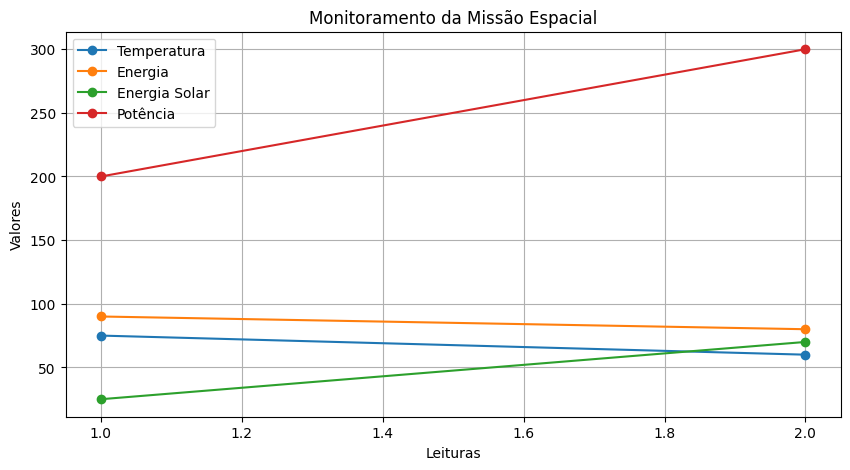


      ECOSPACE MONITORAMENTO
1 - Inserir dados da missão
2 - Ver status atual
3 - Análise completa
4 - Mostrar gráficos
5 - Relatório de sustentabilidade
6 - Sair


In [ ]:
menu()